# Corpus Masterclass 3b: Nietzsche, German, and Paragraph-Level Networks

The corpus is fifteen of Nietzsche's books in German, read from a folder of text files. The pipeline is familiar from the earlier notebooks, with three differences: the corpus comes from disk rather than a library, the language is German with historic spellings, and the unit of analysis switches from whole books to individual paragraphs for the concept networks.

## Today's goal

1. Load fifteen Nietzsche books from a folder of text files.
2. Run the standard pipeline in German: stopwords, document-feature matrix, word cloud, topics, dendrogram.
3. Draw lexical-dispersion plots for German moral-vocabulary roots, via a function.
4. Apply a moral-psychology dictionary at the book level.
5. Reshape the corpus to one row per paragraph.
6. Build a concept egonet: a co-occurrence network restricted to paragraphs that mention a chosen concept, via a function called in a loop.

In [1]:
# Libraries used throughout the notebook.
from pathlib import Path
import pandas
import numpy
import re
import liwc
import matplotlib.pyplot as plt
import nltk
import nltk.corpus
import sklearn.feature_extraction.text
import sklearn.decomposition
import scipy.spatial.distance
import scipy.cluster.hierarchy
import wordcloud
import networkx
from corpus_tools import liwcalike

print('Libraries imported.')

Libraries imported.


In [2]:
# pathlib.Path points at the corpus folder. glob('*.txt') lists every text file; sorted
# makes the order stable.
txt_paths = sorted(Path('nietzsche').glob('*.txt'))
print(f'{len(txt_paths)} files.')
for path in txt_paths[:3]:
    print(f'  {path.name}')

15 files.
  1872 BT.txt
  1873 DS.txt
  1874 HL.txt


In [3]:
# Each filename is 'YEAR CODE.txt', for example '1885 Z.txt' for Thus Spake Zarathustra.
# Read every book, splitting the filename stem to recover the year and book code.
rows = []
for path in txt_paths:
    pieces = path.stem.split(' ')
    rows.append({
        'year': int(pieces[0]),
        'book_code': pieces[1],
        'text': path.read_text(encoding='utf-8'),
    })

nietzsche_df = pandas.DataFrame(rows)
nietzsche_df[['year', 'book_code']]

,year,book_code
0,1872,BT
1,1873,DS
2,1874,HL
3,1874,SE
4,1876,RWB
5,1880,HH
6,1881,D
7,1885,Z
8,1886,BGE
9,1887,GM


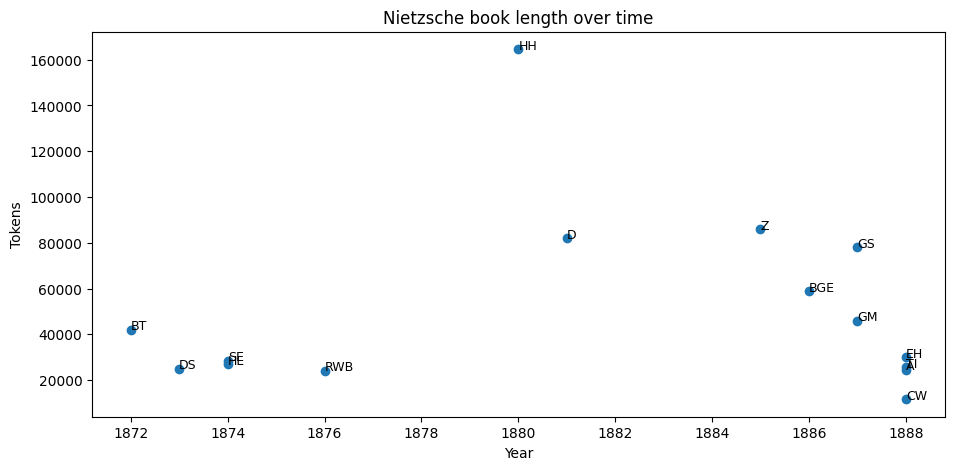

In [4]:
# Book length in tokens (whitespace-separated words), labelled by book code.
nietzsche_df['tokens'] = nietzsche_df['text'].str.split().str.len()

plt.figure(figsize=(11, 5))
plt.scatter(nietzsche_df['year'], nietzsche_df['tokens'])
for _, row in nietzsche_df.iterrows():
    plt.annotate(row['book_code'], (row['year'], row['tokens']), fontsize=9)
plt.xlabel('Year')
plt.ylabel('Tokens')
plt.title('Nietzsche book length over time')
plt.show()

In [5]:
# Tokenise every book. The word pattern handles German letters.
nietzsche_tokens = []
for text in nietzsche_df['text']:
    nietzsche_tokens.append(re.findall(r'\w+', text.lower()))

print(f'{len(nietzsche_tokens[0]):,} tokens in the first book.')

41,947 tokens in the first book.


In [6]:
# German stopwords ship with nltk. The download is a one-time fetch.
nltk.download('stopwords', quiet=True)
german_stop = set(nltk.corpus.stopwords.words('german'))
print(f'{len(german_stop)} standard German stopwords.')

232 standard German stopwords.


In [7]:
# The standard list misses 19th-century forms. update adds several at once.
german_stop.update(['dass', 'mehr', 'immer', 'ja', 'wer', 'sei', 'diess'])
print(f'{len(german_stop)} stopwords after adding historic forms.')

238 stopwords after adding historic forms.


In [8]:
# Build the document-feature matrix with the extended German stopword set.
vectorizer = sklearn.feature_extraction.text.CountVectorizer(
    lowercase=True,
    stop_words=list(german_stop),
)
dfm = vectorizer.fit_transform(nietzsche_df['text'])
features = vectorizer.get_feature_names_out()
print(f'DFM: {dfm.shape[0]} books by {dfm.shape[1]} features.')

DFM: 15 books by 47016 features.


In [9]:
# Top 20 features across the corpus.
totals = dfm.toarray().sum(axis=0)
order = totals.argsort()[::-1]
for rank in range(20):
    word_index = order[rank]
    print(f'{features[word_index]:20s}  {totals[word_index]}')

menschen              2258
leben                 1380
selber                1214
mensch                1103
giebt                 1076
macht                 1058
welt                  1048
art                   981
gerade                954
zeit                  941
vielleicht            925
schon                 831
kunst                 757
zarathustra           694
seele                 687
gut                   680
wahrheit              678
grossen               670
natur                 653
eben                  639


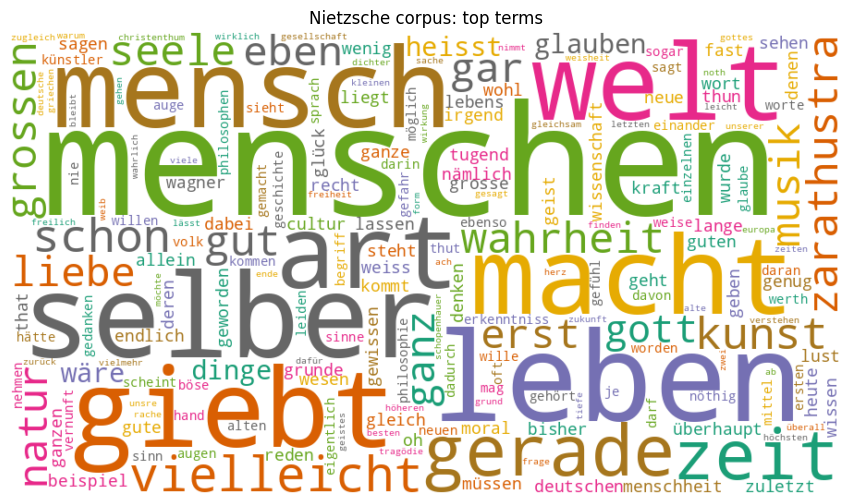

In [10]:
# Word cloud of the corpus. Build the frequency dict with an explicit loop.
word_freq = {}
for word_index, total in enumerate(totals):
    word_freq[features[word_index]] = int(total)

wc = wordcloud.WordCloud(
    width=900,
    height=500,
    background_color='white',
    colormap='Dark2',
    random_state=100,
).generate_from_frequencies(word_freq)

plt.figure(figsize=(11, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Nietzsche corpus: top terms')
plt.show()

In [11]:
# Topic models over the German corpus.
lda = sklearn.decomposition.LatentDirichletAllocation(
    n_components=8,
    random_state=100,
    max_iter=20,
).fit(dfm)

for topic_index, weights in enumerate(lda.components_):
    top_indices = weights.argsort()[-10:][::-1]
    top_words = []
    for word_index in top_indices:
        top_words.append(features[word_index])
    print(f'Topic {topic_index + 1}: {top_words}')

Topic 1: ['angegriffen', 'zurückzudrängen', 'concrete', 'gestörte', 'regulirt', 'antichrist', 'verbesserten', 'auszuwittern', 'verallgemeinern', 'selbstgefällig']
Topic 2: ['angegriffen', 'zurückzudrängen', 'concrete', 'gestörte', 'regulirt', 'antichrist', 'verbesserten', 'auszuwittern', 'verallgemeinern', 'selbstgefällig']
Topic 3: ['menschen', 'leben', 'selber', 'zeit', 'macht', 'giebt', 'mensch', 'vielleicht', 'gerade', 'welt']
Topic 4: ['zarathustra', 'selber', 'menschen', 'oh', 'sprach', 'liebe', 'gleich', 'wahrlich', 'schon', 'leben']
Topic 5: ['musik', 'tragödie', 'kunst', 'welt', 'dionysischen', 'mythus', 'natur', 'menschen', 'leben', 'apollinischen']
Topic 6: ['menschen', 'art', 'mensch', 'moral', 'giebt', 'macht', 'gerade', 'vielleicht', 'leben', 'heute']
Topic 7: ['wagner', 'musik', 'kunst', 'deutschen', 'leben', 'zarathustra', 'wort', 'art', 'nie', 'vielleicht']
Topic 8: ['angegriffen', 'zurückzudrängen', 'concrete', 'gestörte', 'regulirt', 'antichrist', 'verbesserten', 'au

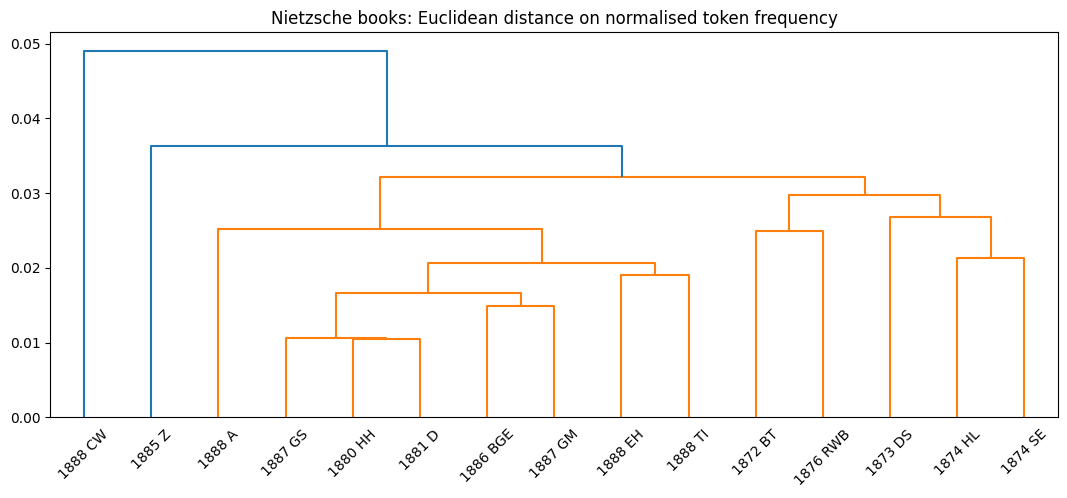

In [12]:
# Hierarchical clustering of the fifteen books. Row-normalise, then dendrogram.
dense = dfm.toarray().astype(float)
row_totals = dense.sum(axis=1, keepdims=True)
row_totals[row_totals == 0] = 1.0
normalised = dense / row_totals

book_labels = []
for _, row in nietzsche_df.iterrows():
    book_labels.append(f'{row["year"]} {row["book_code"]}')

distances = scipy.spatial.distance.pdist(normalised, metric='euclidean')
linkage = scipy.cluster.hierarchy.linkage(distances, method='complete')
plt.figure(figsize=(13, 5))
scipy.cluster.hierarchy.dendrogram(linkage, labels=book_labels, leaf_rotation=45, leaf_font_size=10)
plt.title('Nietzsche books: Euclidean distance on normalised token frequency')
plt.show()

In [13]:
# dispersion_plot shows where a set of word-roots appear within each book, in absolute
# token position. A token counts if it starts with any of the prefixes. The grey bar is
# the length of the book, and each black mark is one occurrence.
def dispersion_plot(prefixes, title):
    plt.figure(figsize=(11, 5))
    for plot_row, tokens in enumerate(nietzsche_tokens):
        plt.hlines(plot_row, 0, len(tokens), color='lightgray', linewidth=6, zorder=1)
        marks = []
        for token_index, token in enumerate(tokens):
            for prefix in prefixes:
                if token.startswith(prefix):
                    marks.append(token_index)
                    break
        plt.scatter(marks, [plot_row] * len(marks), marker='|', s=80, color='black', zorder=2)
    plt.yticks(range(len(book_labels)), book_labels, fontsize=8)
    plt.xlabel('Token index')
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()

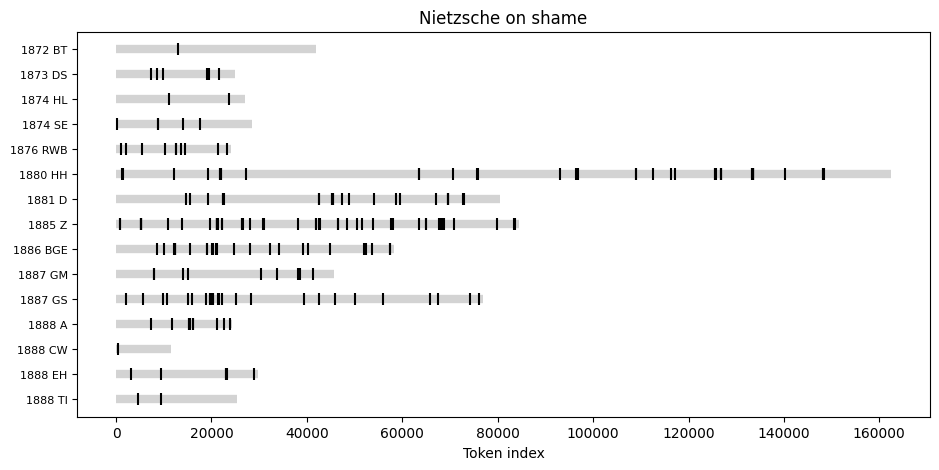

In [14]:
# Shame: scham, schmach, schand.
dispersion_plot(['scham', 'schmach', 'schand'], 'Nietzsche on shame')

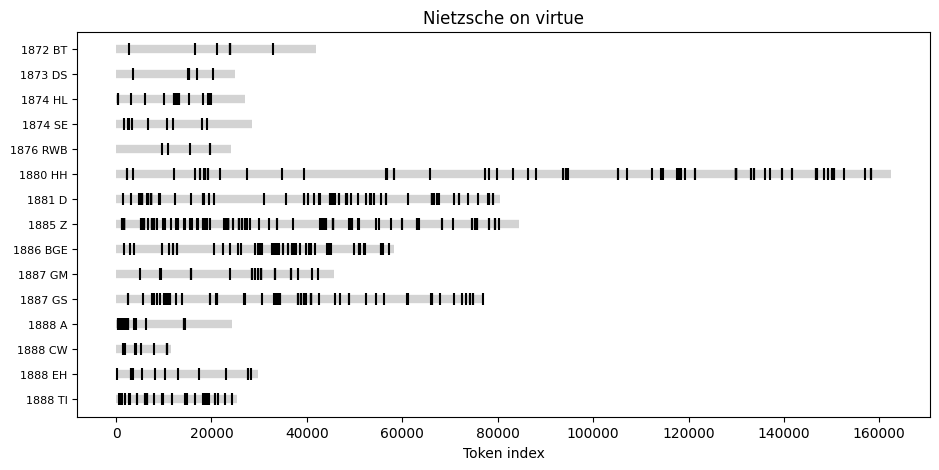

In [15]:
# Virtue: tugend.
dispersion_plot(['tugend'], 'Nietzsche on virtue')

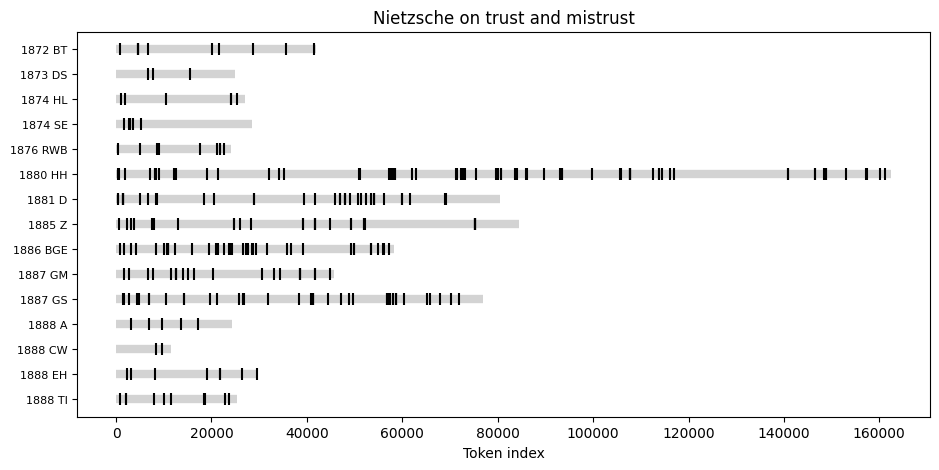

In [16]:
# Trust and mistrust: vertrau, misstrau.
dispersion_plot(['vertrau', 'misstrau'], 'Nietzsche on trust and mistrust')

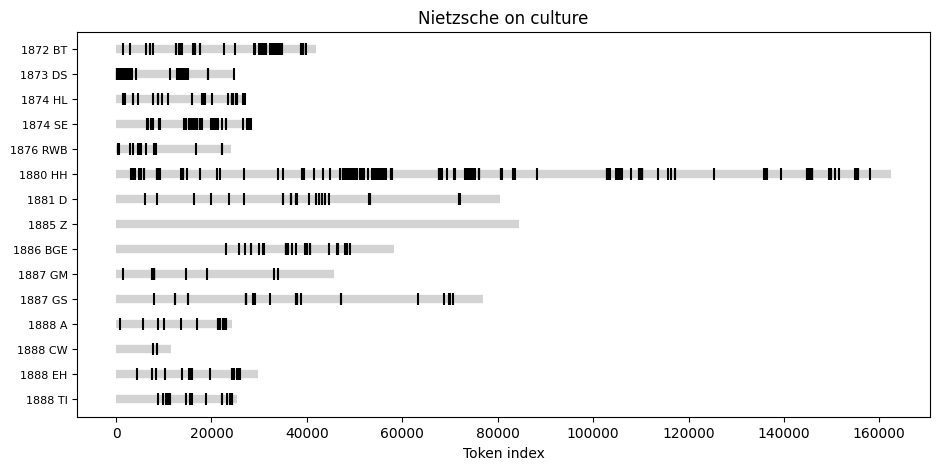

In [17]:
# Culture: kultur, cultur.
dispersion_plot(['kultur', 'cultur'], 'Nietzsche on culture')

In [18]:
# Load the Nietzsche moral-psychology dictionary. liwcalike does the matching, including
# the trailing-* wildcard that catches historic spellings. Here we just read off its names.
_, n_names = liwc.load_token_parser('dictionaries/nietzsche.dic')
print(f'{len(n_names)} categories: {n_names[:8]} ...')

54 categories: ['admiration', 'affect', 'anger', 'base', 'chastity', 'comedy', 'conscience', 'contempt'] ...


In [19]:
# liwcalike applies the dictionary to every book at once. Each category becomes a
# percentage of the book's word count, reported next to WC, words per sentence (WPS),
# and the share of long words (Sixltr).
book_feature_df = liwcalike(list(nietzsche_df['text']), book_labels, 'dictionaries/nietzsche.dic')
book_feature_df['book_code'] = list(nietzsche_df['book_code'])
book_feature_df['year'] = list(nietzsche_df['year'])
book_feature_df.head(3)

,docname,WC,WPS,Sixltr,Dic,admiration,affect,anger,base,chastity,...,tragedy,trust,type,value,virtue,vice,wtp,reverence,book_code,year
0,1872 BT,41947,34.410993,32.23,1.50,0.00,0.03,0.0,0.01,0.0,...,0.37,0.02,0.02,0.04,0.02,0.00,0.0,0.00,BT,1872
1,1873 DS,25009,26.380802,29.75,1.40,0.03,0.02,0.0,0.00,0.0,...,0.00,0.01,0.02,0.06,0.02,0.00,0.0,0.00,DS,1873
2,1874 HL,26944,35.546174,29.36,1.83,0.03,0.00,0.0,0.01,0.0,...,0.00,0.02,0.02,0.06,0.08,0.01,0.0,0.01,HL,1874


In [20]:
# Helper. Plot one liwcalike column across the books, labelled by book code.
def plot_book_metric(column, ylabel, title):
    ordered = book_feature_df.sort_values('year')
    plt.figure(figsize=(11, 3.5))
    plt.scatter(ordered['year'], ordered[column])
    for _, row in ordered.iterrows():
        plt.annotate(row['book_code'], (row['year'], row[column]), fontsize=8)
    plt.xlabel('Year')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.show()

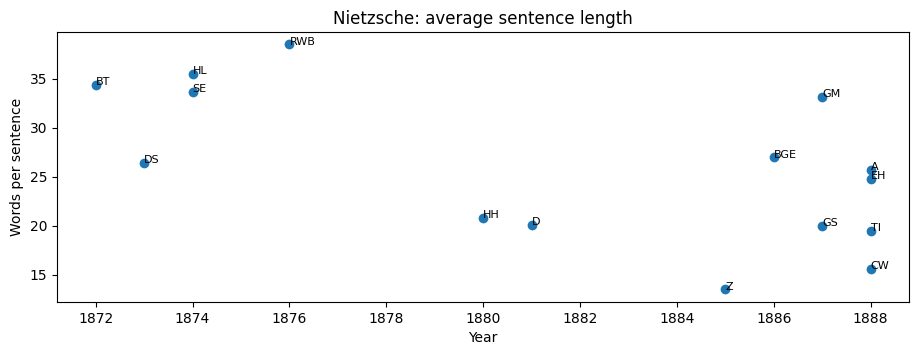

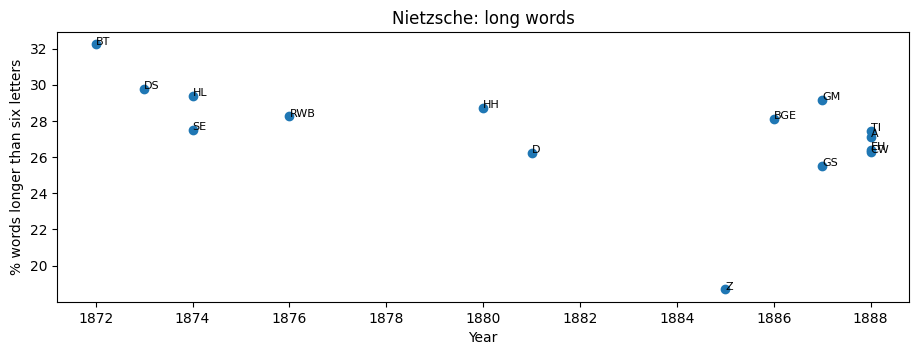

In [21]:
# Average sentence length and the share of long words come straight from liwcalike.
plot_book_metric('WPS', 'Words per sentence', 'Nietzsche: average sentence length')
plot_book_metric('Sixltr', '% words longer than six letters', 'Nietzsche: long words')

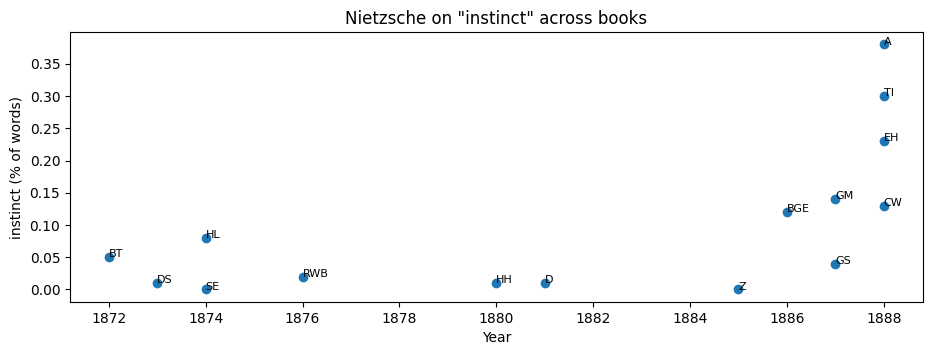

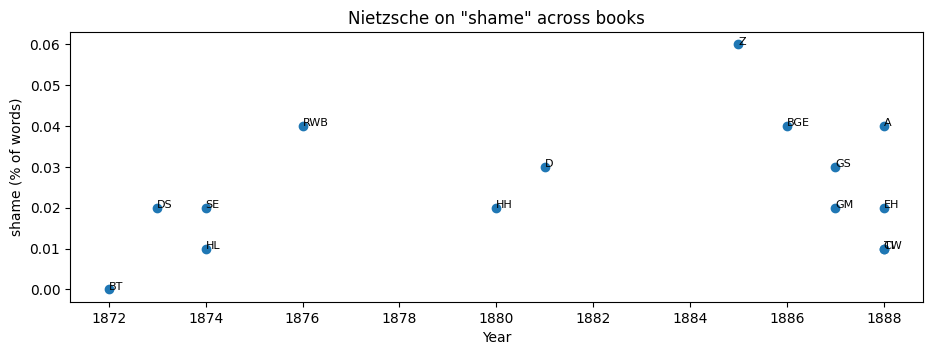

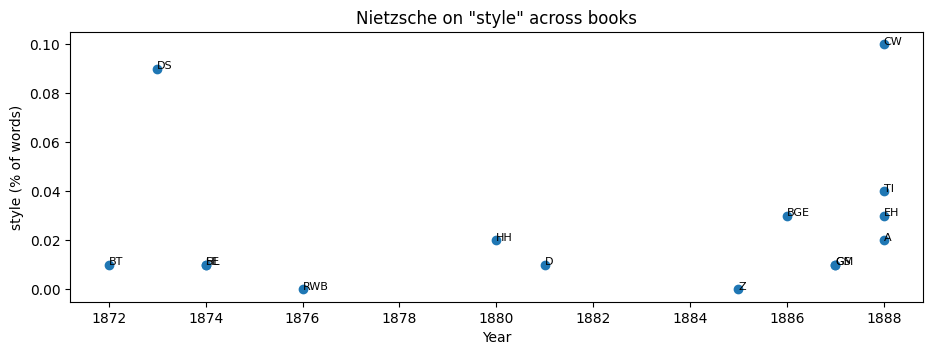

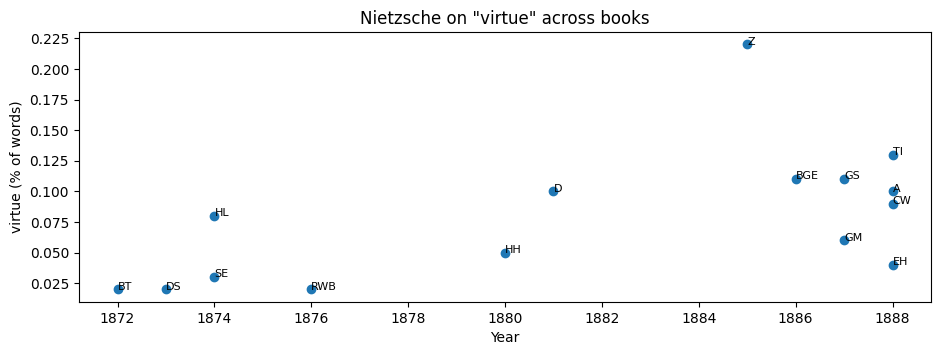

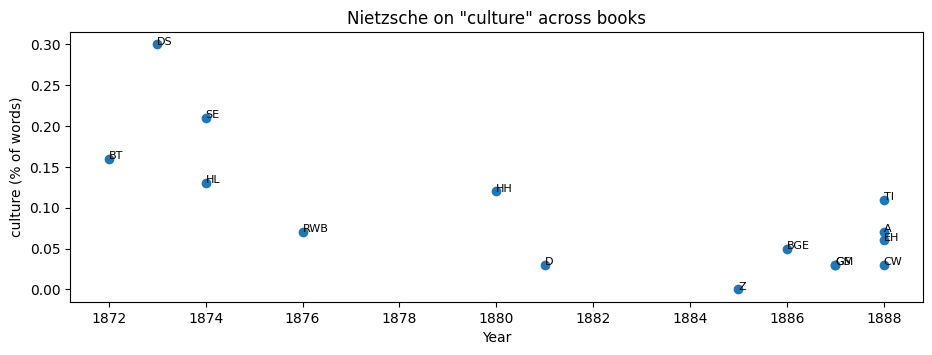

In [22]:
# A few moral categories across the books, each as a percentage of the book's words.
for name in ['instinct', 'shame', 'style', 'virtue', 'culture']:
    if name not in book_feature_df.columns:
        continue
    plot_book_metric(name, f'{name} (% of words)', f'Nietzsche on "{name}" across books')

In [23]:
# Reshape to paragraphs. Splitting on blank lines turns fifteen long books into thousands
# of short documents, so a concept that appears in one paragraph does not register as
# co-occurring with concepts elsewhere in the same book.
paragraph_rows = []
for _, book in nietzsche_df.iterrows():
    for paragraph in book['text'].split('\n\n'):
        cleaned = paragraph.strip()
        if len(cleaned) < 50:
            continue
        paragraph_rows.append({'book_code': book['book_code'], 'text': cleaned})

paragraph_df = pandas.DataFrame(paragraph_rows)
print(f'{len(paragraph_df)} paragraphs from {len(nietzsche_df)} books.')

7265 paragraphs from 15 books.


In [24]:
# liwcalike again, now one row per paragraph. Each category is a percentage of the
# paragraph's word count, so a short paragraph and a long one sit on the same scale.
paragraph_names = []
for paragraph_index in range(len(paragraph_df)):
    paragraph_names.append(f'para_{paragraph_index}')

paragraph_feature_df = liwcalike(list(paragraph_df['text']), paragraph_names, 'dictionaries/nietzsche.dic')
paragraph_feature_df.head(3)

,docname,WC,WPS,Sixltr,Dic,admiration,affect,anger,base,chastity,...,style,surprise,tragedy,trust,type,value,virtue,vice,wtp,reverence
0,para_0,8,4.000000,37.50,12.50,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,12.50,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,para_1,13,2.166667,30.77,0.00,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,para_2,233,19.416667,29.18,2.58,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.72,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# concept_egonet restricts to paragraphs that mention a concept, then builds the
# co-occurrence network among all categories there. The graph is nearly complete, so we
# keep only the strongest links and drop categories left isolated. A force-directed
# layout shapes the rest; node size grows with frequency and faint edges are weaker.
def concept_egonet(concept_name, top_edges=50):
    if concept_name not in paragraph_feature_df.columns:
        print(f'{concept_name}: not a dictionary category.')
        return
    subset = paragraph_feature_df[paragraph_feature_df[concept_name] > 0]
    if len(subset) < 5:
        print(f'{concept_name}: only {len(subset)} paragraphs match.')
        return
    matrix = subset[n_names].to_numpy()
    adjacency = matrix.T @ matrix
    graph = networkx.from_numpy_array(adjacency)
    relabelling = {}
    for node_index, name in enumerate(n_names):
        relabelling[node_index] = name
    graph = networkx.relabel_nodes(graph, relabelling)
    graph.remove_edges_from(list(networkx.selfloop_edges(graph)))
    # Rank the edges by weight, keep the strongest, and drop nodes left with none.
    ranked_edges = []
    for u, v in graph.edges():
        ranked_edges.append((graph[u][v]['weight'], u, v))
    def by_weight(item):
        return item[0]
    ranked_edges = sorted(ranked_edges, key=by_weight, reverse=True)
    for weight, u, v in ranked_edges[top_edges:]:
        graph.remove_edge(u, v)
    graph.remove_nodes_from(list(networkx.isolates(graph)))
    weights = []
    for u, v in graph.edges():
        weights.append(graph[u][v]['weight'])
    largest = max(weights) if weights else 1
    widths = []
    edge_colors = []
    for weight in weights:
        widths.append(weight / largest * 5)
        shade = 0.85 - 0.7 * (weight / largest)
        edge_colors.append((shade, shade, shade))
    category_totals = subset[n_names].sum(axis=0)
    biggest = category_totals.max() if category_totals.max() > 0 else 1
    node_sizes = []
    for node in graph.nodes():
        node_sizes.append(250 + category_totals[node] / biggest * 1900)
    plt.figure(figsize=(10, 9))
    networkx.draw(
        graph,
        pos=networkx.spring_layout(graph, seed=42, weight='weight'),
        with_labels=True,
        node_color='lightgray',
        node_size=node_sizes,
        edge_color=edge_colors,
        width=widths,
        font_size=8,
    )
    plt.title(f'Concept egonet: {concept_name} ({len(subset)} paragraphs, top {top_edges} links)')
    plt.show()

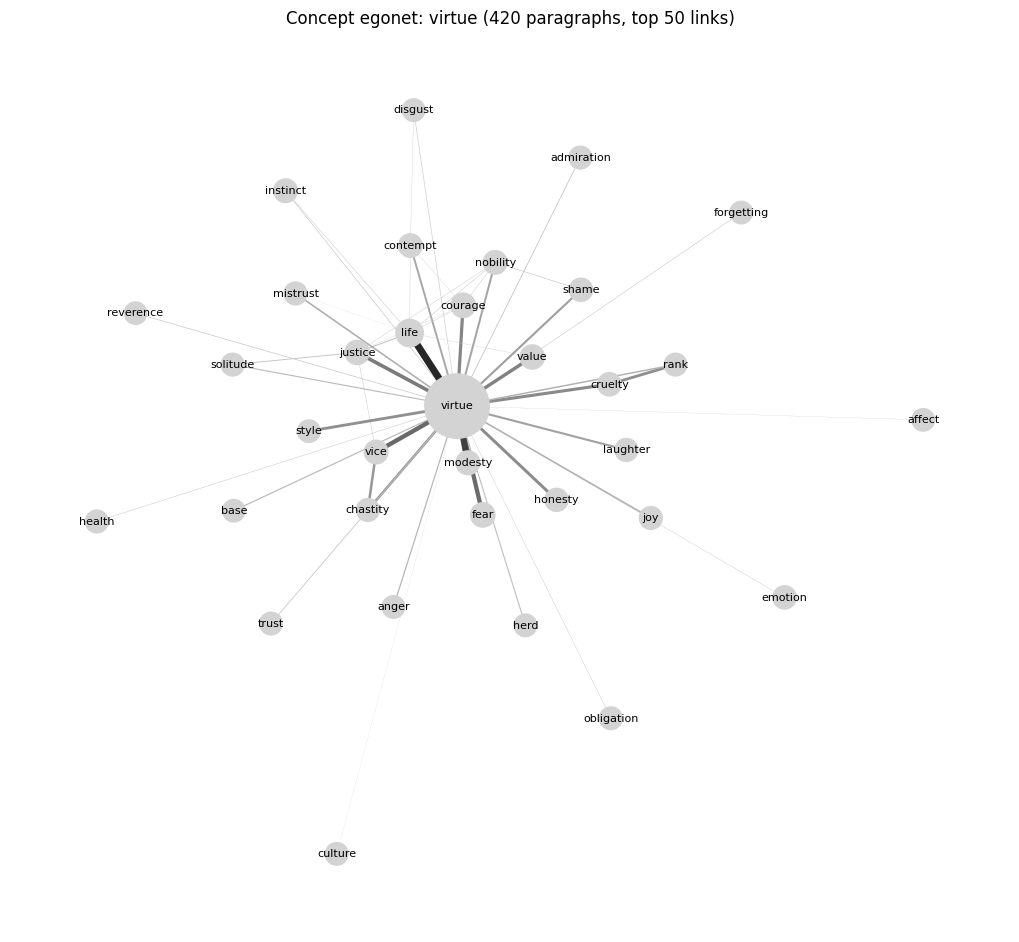

In [26]:
# One worked concept.
concept_egonet('virtue')

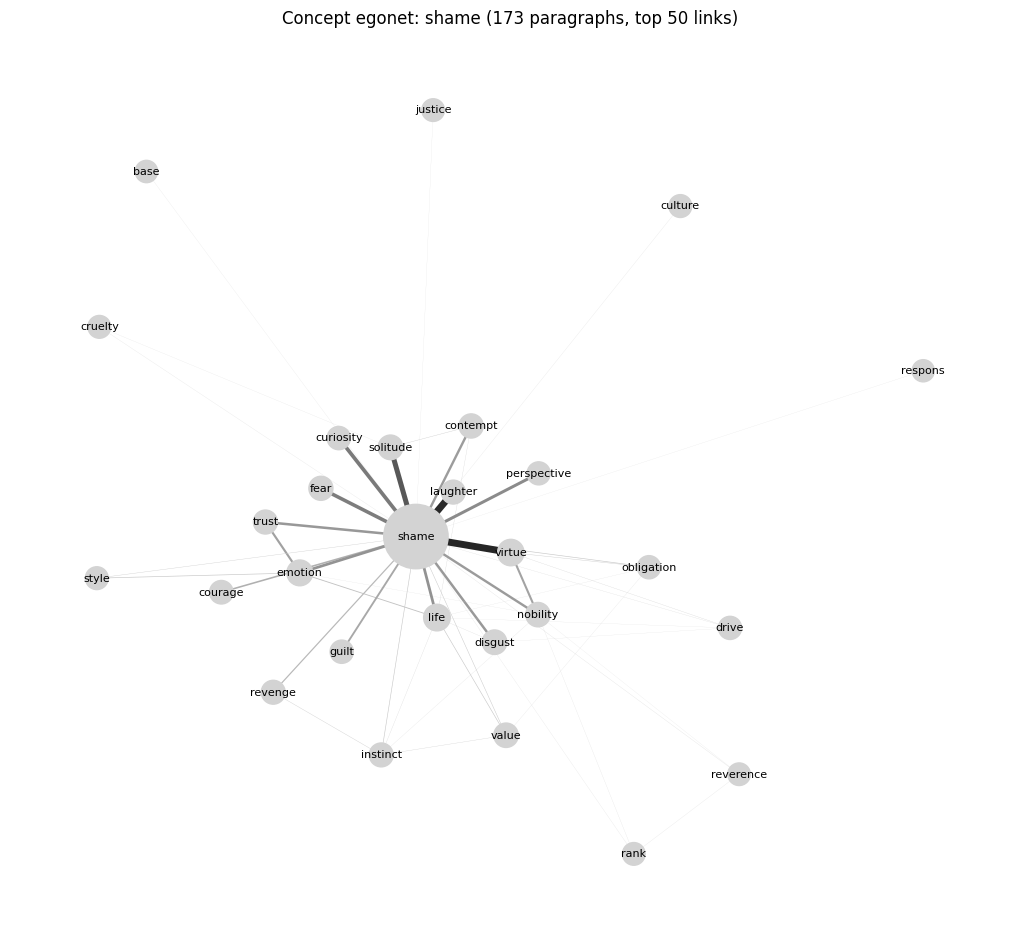

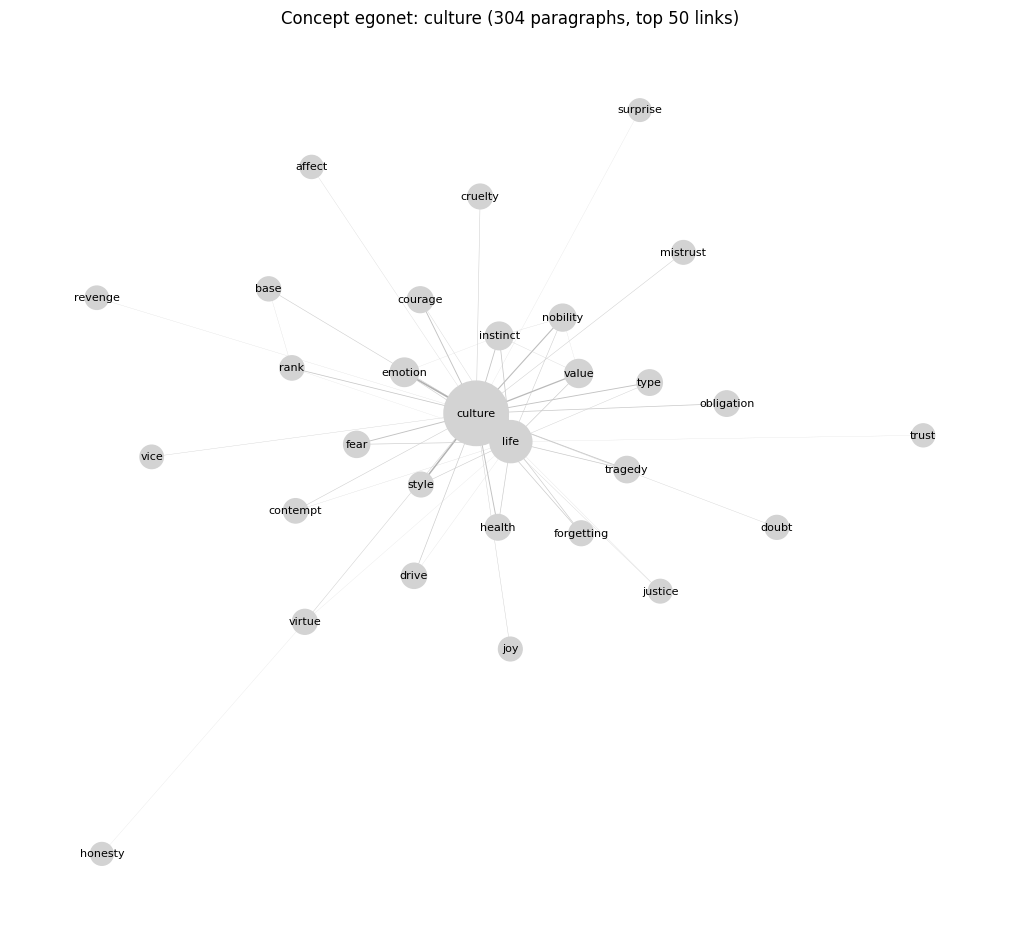

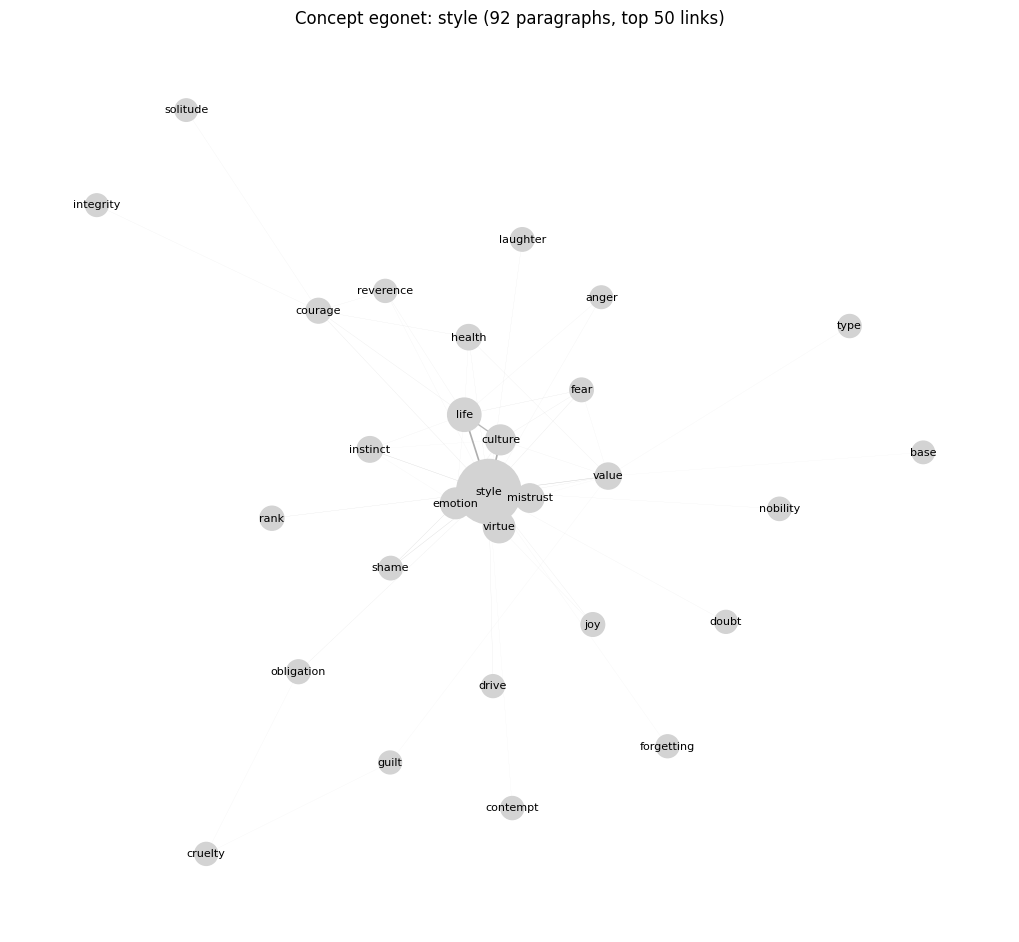

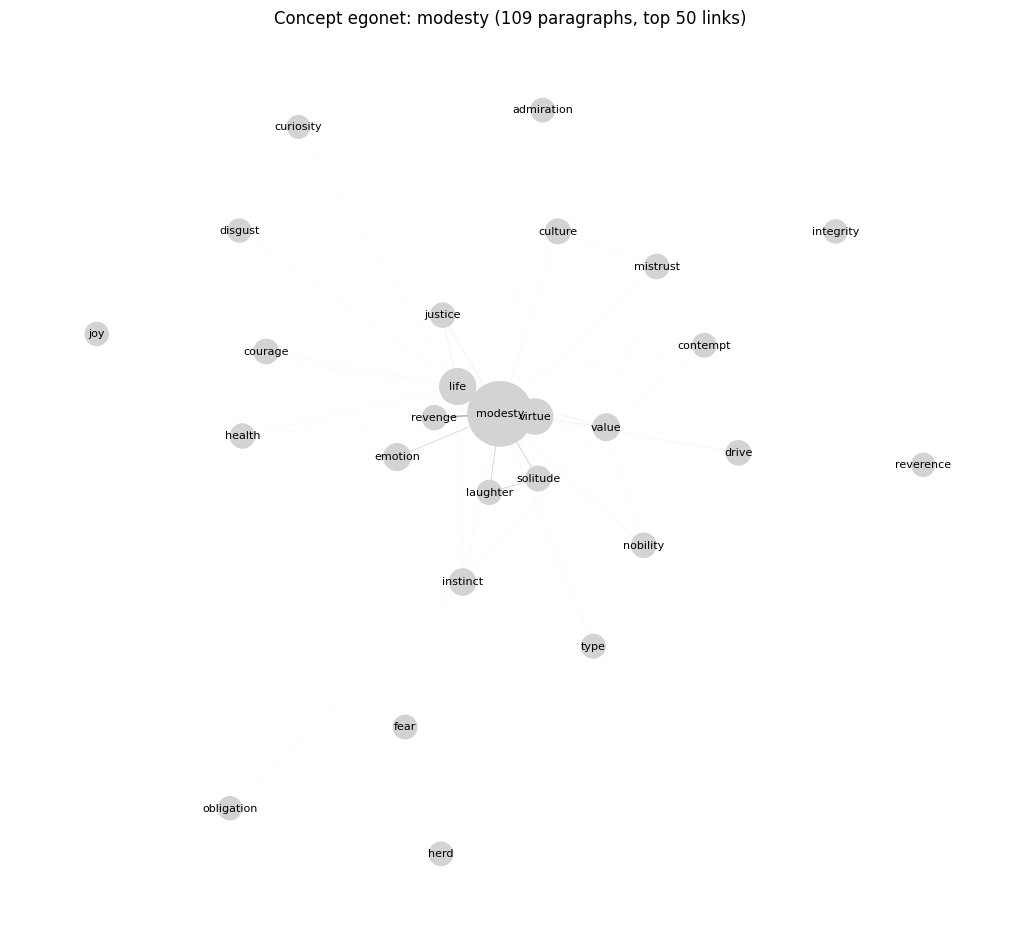

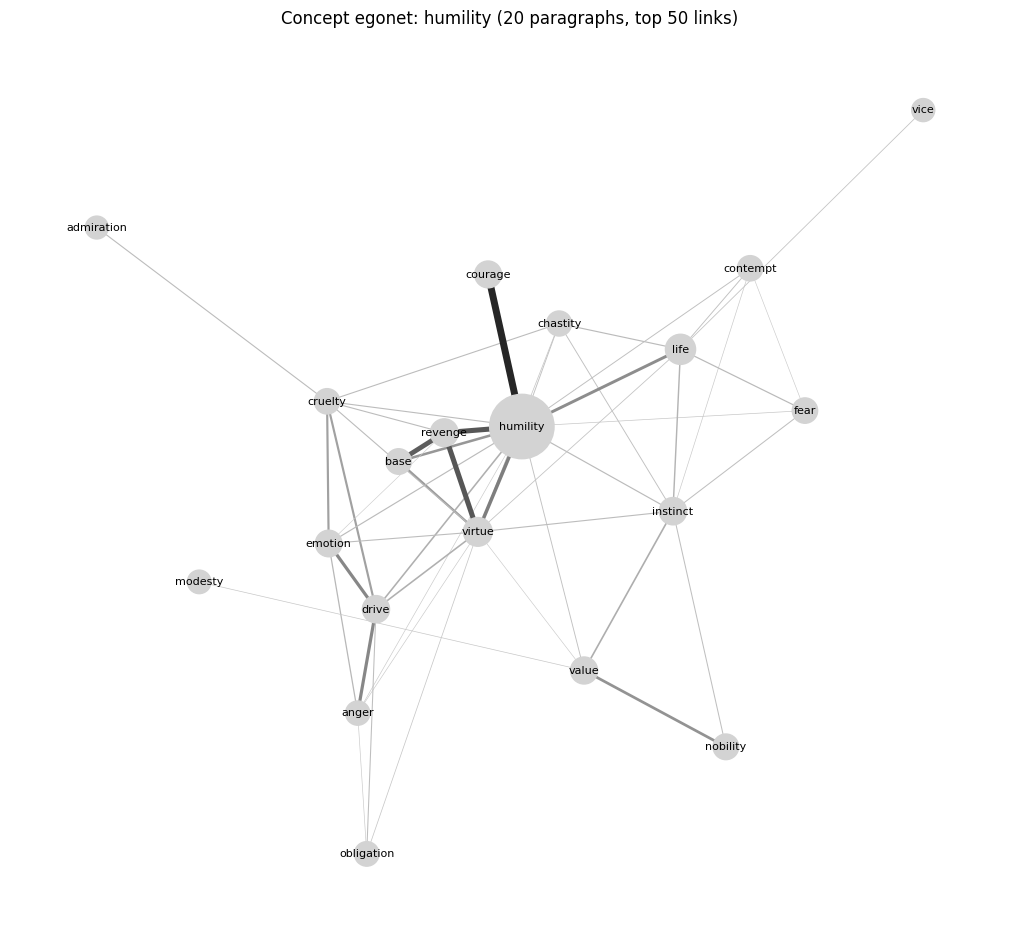

In [27]:
# Several concepts, one call each.
for concept in ['shame', 'culture', 'style', 'modesty', 'humility']:
    concept_egonet(concept)

In [28]:
# split_inside_outside captures the keyword windows around a set of prefixes. Reused for
# both kultur and tugend below. The keyword tokens themselves are left out of the inside
# list: they appear in every window by definition, so keeping them would just rank the
# search word at the top of its own keyness. We want the words around it.
def split_inside_outside(tokens, prefixes, window=10):
    near_match = [False] * len(tokens)
    for index, token in enumerate(tokens):
        for prefix in prefixes:
            if token.startswith(prefix):
                start = max(0, index - window)
                end = min(len(tokens), index + window + 1)
                for marker in range(start, end):
                    near_match[marker] = True
                break
    inside = []
    outside = []
    for index, token in enumerate(tokens):
        is_keyword = False
        for prefix in prefixes:
            if token.startswith(prefix):
                is_keyword = True
                break
        if near_match[index] and not is_keyword:
            inside.append(token)
        elif not near_match[index]:
            outside.append(token)
    return inside, outside

In [29]:
# keyness_top ranks the words most distinctive of the inside windows by chi-squared.
import scipy.stats

def keyness_top(inside, outside, top=15):
    inside_counts = {}
    for token in inside:
        inside_counts[token] = inside_counts.get(token, 0) + 1
    outside_counts = {}
    for token in outside:
        outside_counts[token] = outside_counts.get(token, 0) + 1
    total_inside = len(inside)
    total_outside = len(outside)
    scored = []
    for word, inside_count in inside_counts.items():
        if inside_count < 5:
            continue
        outside_count = outside_counts.get(word, 0)
        table = [[inside_count, total_inside - inside_count], [outside_count, total_outside - outside_count]]
        statistic = scipy.stats.chi2_contingency(table).statistic
        scored.append((word, statistic))
    def sort_key(entry):
        return entry[1]
    return sorted(scored, key=sort_key, reverse=True)[:top]

In [30]:
# Gather kultur windows across the whole corpus and rank their keywords.
kultur_inside = []
kultur_outside = []
for tokens in nietzsche_tokens:
    inside, outside = split_inside_outside(tokens, ['kultur', 'cultur'])
    kultur_inside.extend(inside)
    kultur_outside.extend(outside)

print('Keywords inside kultur windows:')
for word, statistic in keyness_top(kultur_inside, kultur_outside):
    print(f'  {word:18s}  chi-squared {statistic:8.1f}')

Keywords inside kultur windows:
  pforte              chi-squared    127.3
  der                 chi-squared    112.4
  barbarei            chi-squared    105.6
  höheren             chi-squared     76.2
  höhere              chi-squared     75.9
  deutschen           chi-squared     55.6
  unserer             chi-squared     49.8
  einer               chi-squared     48.7
  renaissance         chi-squared     45.9
  verschiedenen       chi-squared     41.2
  die                 chi-squared     38.7
  niederen            chi-squared     38.3
  philister           chi-squared     35.1
  hohe                chi-squared     35.1
  ich                 chi-squared     34.0


In [31]:
# The same for tugend.
tugend_inside = []
tugend_outside = []
for tokens in nietzsche_tokens:
    inside, outside = split_inside_outside(tokens, ['tugend'])
    tugend_inside.extend(inside)
    tugend_outside.extend(outside)

print('Keywords inside tugend windows:')
for word, statistic in keyness_top(tugend_inside, tugend_outside):
    print(f'  {word:18s}  chi-squared {statistic:8.1f}')

Keywords inside tugend windows:


  eurer               chi-squared    199.9
  verlogen            chi-squared    191.3
  eure                chi-squared     70.4
  gerechtigkeit       chi-squared     64.6
  grossmuth           chi-squared     62.4
  sokratischen        chi-squared     59.0
  euer                chi-squared     57.0
  laster              chi-squared     54.0
  lohn                chi-squared     47.2
  deine               chi-squared     37.8
  kleinen             chi-squared     33.8
  bescheiden          chi-squared     33.7
  ihr                 chi-squared     33.2
  schlaf              chi-squared     32.4
  unsre               chi-squared     29.4


## What we've covered

**Python:** `pathlib.Path`, `.glob`, `.read_text`; parsing filenames; building a corpus from disk; extending a set with `.update`; reusing helper functions across books and paragraphs; the function-and-loop pattern for concept egonets.

**Corpus linguistics:** working in German; custom stopwords for historic spellings; paragraph-level reshape; concept egonets; bottom-up collocation with keyness across morphological roots.

## Read more

- **NLTK multilingual stopwords**: [https://www.nltk.org/howto/corpus.html#stopwords](https://www.nltk.org/howto/corpus.html#stopwords).
- **pathlib**: [https://docs.python.org/3/library/pathlib.html](https://docs.python.org/3/library/pathlib.html).
- **NetworkX layouts**: [https://networkx.org/documentation/stable/reference/drawing.html#module-networkx.drawing.layout](https://networkx.org/documentation/stable/reference/drawing.html#module-networkx.drawing.layout).
- **scipy.stats.chi2_contingency**: [https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2_contingency.html).
- **Keyness and positive vs negative keywords**: [https://browndw.github.io/textstat_docs/labs/keyness.html](https://browndw.github.io/textstat_docs/labs/keyness.html).